<a href="https://colab.research.google.com/github/Subham-Singh-369/OIBSIP/blob/main/DataScience-Task3-CarPricePrediction/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving CAR DETAILS FROM CAR DEKHO.csv to CAR DETAILS FROM CAR DEKHO.csv


In [3]:
import pandas as pd
df = pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv')  # match your actual filename
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [5]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nUnique fuel types:", df['fuel'].unique())
print("Unique seller types:", df['seller_type'].unique())
print("Unique transmissions:", df['transmission'].unique())
print("Unique owner types:", df['owner'].unique())

Shape: (4340, 8)

Data types:
 name             object
year              int64
selling_price     int64
km_driven         int64
fuel             object
seller_type      object
transmission     object
owner            object
dtype: object

Missing values:
 name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Duplicate rows: 763

Unique fuel types: ['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']
Unique seller types: ['Individual' 'Dealer' 'Trustmark Dealer']
Unique transmissions: ['Manual' 'Automatic']
Unique owner types: ['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car']


In [6]:
# Remove duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows.")

# Feature engineering: car age (dataset is from ~2020, so use 2020 as reference)
df['car_age'] = 2020 - df['year']

# Extract brand from the car name (first word)
df['brand'] = df['name'].apply(lambda x: x.split()[0])

df[['name', 'brand', 'year', 'car_age']].head()

Removed 763 duplicate rows.


,name,brand,year,car_age
0,Maruti 800 AC,Maruti,2007,13
1,Maruti Wagon R LXI Minor,Maruti,2007,13
2,Hyundai Verna 1.6 SX,Hyundai,2012,8
3,Datsun RediGO T Option,Datsun,2017,3
4,Honda Amaze VX i-DTEC,Honda,2014,6


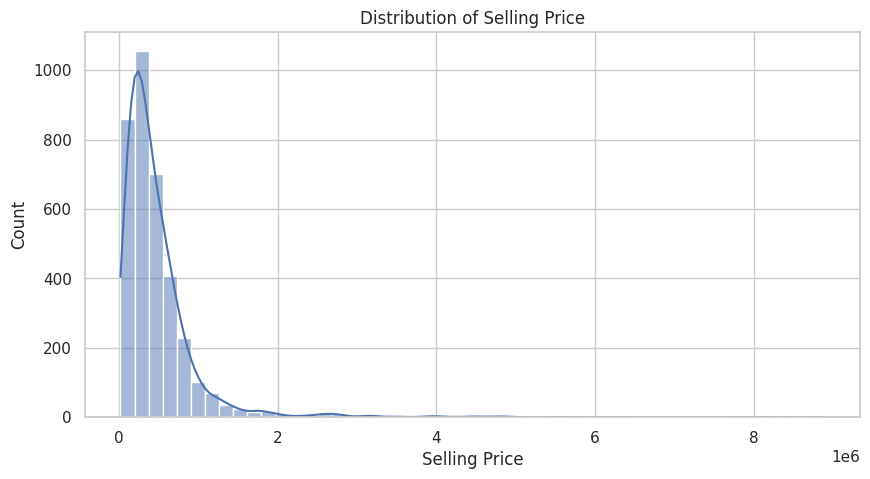

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['selling_price'], bins=50, kde=True)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.show()

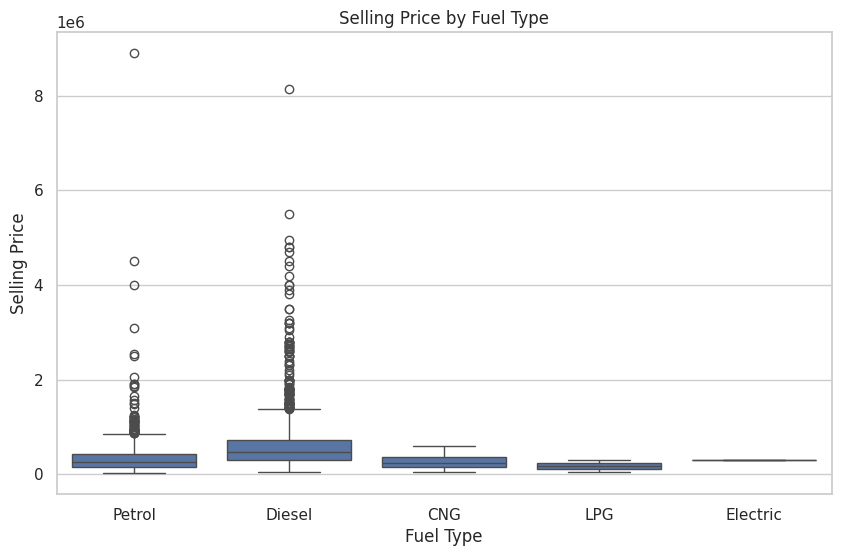

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='fuel', y='selling_price')
plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.show()

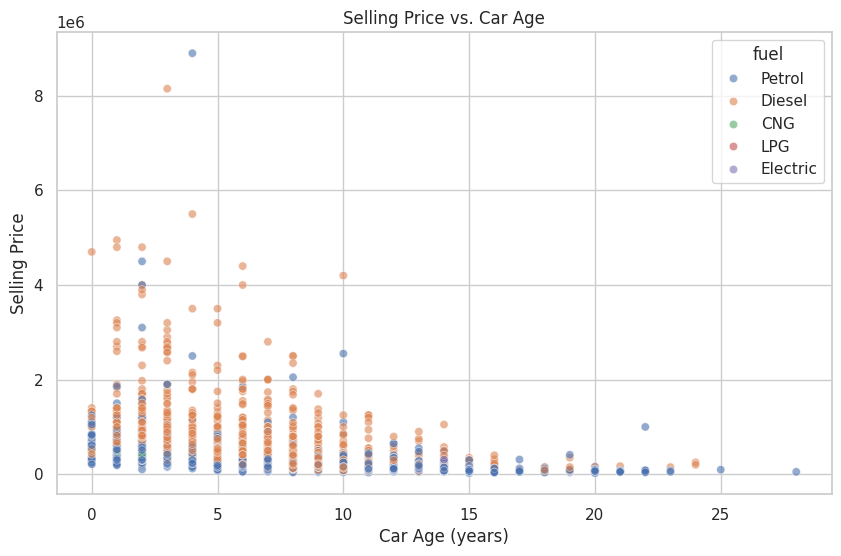

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='car_age', y='selling_price', hue='fuel', alpha=0.6)
plt.title('Selling Price vs. Car Age')
plt.xlabel('Car Age (years)')
plt.ylabel('Selling Price')
plt.show()

In [10]:
df_encoded = pd.get_dummies(df, columns=['fuel', 'seller_type', 'transmission', 'owner', 'brand'], drop_first=True)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (3577, 44)


,name,year,selling_price,km_driven,car_age,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_OpelCorsa,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,Maruti 800 AC,2007,60000,70000,13,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
1,Maruti Wagon R LXI Minor,2007,135000,50000,13,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
2,Hyundai Verna 1.6 SX,2012,600000,100000,8,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,Datsun RediGO T Option,2017,250000,46000,3,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
4,Honda Amaze VX i-DTEC,2014,450000,141000,6,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


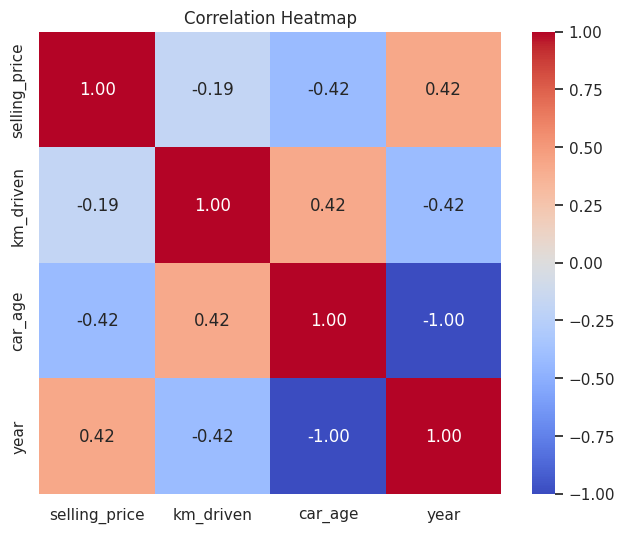

In [11]:
numeric_for_corr = ['selling_price', 'km_driven', 'car_age', 'year']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_for_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap')
plt.show()

In [12]:
X = df_encoded.drop(columns=['name', 'selling_price', 'year'])  # drop raw name, target, and redundant year (we have car_age)
y = df_encoded['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (2861, 41)
Test set size: (716, 41)


In [13]:
# Model 1: Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

# Model 2: Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

print("Models trained successfully.")

Models trained successfully.


In [14]:
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"=== {model_name} ===")
    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²:   {r2:.4f}\n")
    return mae, rmse, r2

lin_metrics = evaluate(y_test, y_pred_lin, "Linear Regression")
rf_metrics = evaluate(y_test, y_pred_rf, "Random Forest Regressor")

=== Linear Regression ===
MAE:  180,194.99
RMSE: 385,606.09
R²:   0.5384

=== Random Forest Regressor ===
MAE:  158,970.51
RMSE: 368,858.98
R²:   0.5776

